In [ ]:
# Uncomment if running for the first time in Colab

!pip install -q pandas numpy scikit-learn matplotlib seaborn missingno openpyxl

In [ ]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno

from google.colab import drive

In [ ]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
PROJECT_DIR="/content/drive/MyDrive/Ghana_Dropout_Project"

os.makedirs(PROJECT_DIR,exist_ok=True)

In [ ]:
df=pd.read_excel(
    f"{PROJECT_DIR}/ghana_dropout_study_M.xlsx"
)

print(df.shape)

df.head()

(1000, 48)


,Study ID,Academic Year\n,School Code\n,District,Geographic Zone,School Type,Data Source,Enumerator Initials,Date Recorded\n,Gender,...,Missed School due to Illness,Barriers to Regular Attendance,Family Income Level,Parent Attends School Events,Behaviour Warnings /Punishments,Class Participation,Extra-curricular Activities,DROPOUT LABEL,Headteacher Confirmation Date,Notes /\nComments
0,KNUST_J_1,2024/25,KNU_JHS,Kumasi Metro,Peri-urban,Public,Questionnaire,OKT,2026-07-05 00:00:00,Male,...,"Yes, more than once",Nothing-come regularly,Medium,Sometimes,Never,5.0,1 activity,0 - Retained,2026-07-05 00:00:00,NaN
1,KNUST_J_2,2024/25,KNU_JHS,Kumasi Metro,Peri-urban,Public,Questionnaire,ET,2026-07-05 00:00:00,Male,...,"Yes, more than once",Nothing-come regularly,Medium,Rarely,Once,2.0,2 activities,0 - Retained,2026-07-05 00:00:00,NaN
2,KNUST_J_3,2024/25,KNU_JHS,Kumasi Metro,Peri-urban,Public,Questionnaire,KCJ,2026-07-05 00:00:00,Male,...,"Yes, more than once",Health problems,Medium,Sometimes,Never,5.0,2 activities,0 - Retained,2026-07-05 00:00:00,NaN
3,KNUST_J_4,2024/25,KNU_JHS,Kumasi Metro,Peri-urban,Public,Questionnaire,OKT,2026-07-05 00:00:00,Female,...,"Yes, once",Nothing-come regularly,High,Often,Never,4.0,2 activities,0 - Retained,2026-07-05 00:00:00,NaN
4,KNUST_J_5,2024/25,KNU_JHS,Kumasi Metro,Peri-urban,Public,Questionnaire,VT,2026-07-05 00:00:00,Female,...,"Yes, more than once",Nothing-come regularly,High,Sometimes,Never,4.0,1 activity,0 - Retained,2026-07-05 00:00:00,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 48 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Study ID                          1000 non-null   object 
 1   Academic Year
                    1000 non-null   object 
 2   School Code
                      1000 non-null   object 
 3   District                          1000 non-null   object 
 4   Geographic Zone                   1000 non-null   object 
 5   School Type                       1000 non-null   object 
 6   Data Source                       1000 non-null   object 
 7   Enumerator Initials               1000 non-null   object 
 8   Date Recorded
                    1000 non-null   object 
 9   Gender                            1000 non-null   object 
 10  Age at Start of Academic Year     1000 non-null   float64
 11  Class Level                       1000 non-null   object 
 12  Grade R

In [ ]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Study ID,1000,980,WEWE_465,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Academic Year\n,1000,1,2024/25,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
School Code\n,1000,4,WEWE,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
District,1000,1,Kumasi Metro,1000,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Geographic Zone,1000,2,Rural,579,NaN,NaN,NaN,NaN,NaN,NaN,NaN
School Type,1000,2,Public,908,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Data Source,1000,2,Both,924,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Enumerator Initials,1000,5,OKT,557,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Date Recorded\n,1000,4,2026-01-06 00:00:00,500,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Gender,1000,2,Male,524,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
missing=df.isnull().sum()

missing=missing[missing>0]

missing.sort_values(ascending=False)

,0
Notes /\nComments,1000
Extra-curricular Activities,249
Daily Study Hours at Home,32
No. of Siblings in School,9
Class Participation,2
Term 2 Attendance\n,1


<Figure size 1200x600 with 0 Axes>

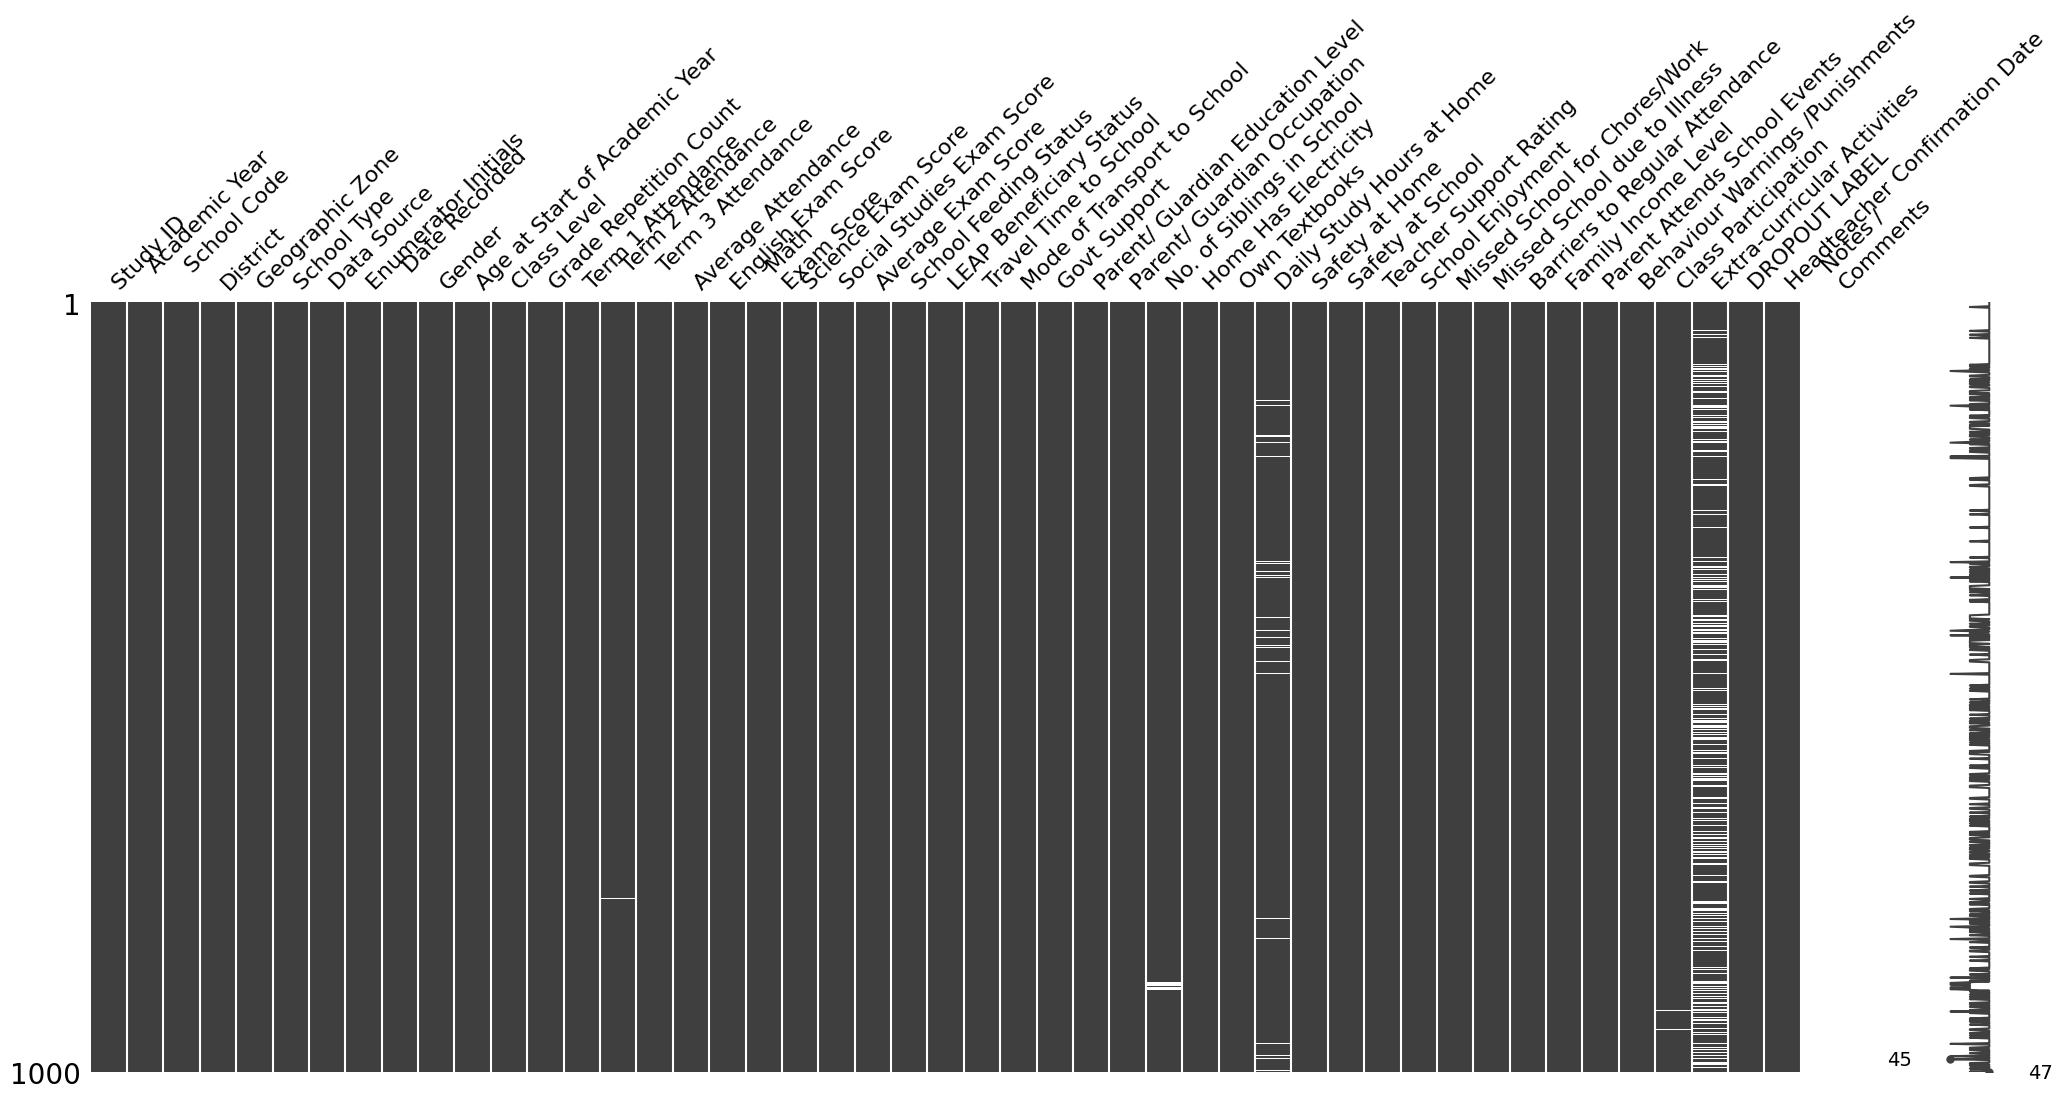

In [ ]:
plt.figure(figsize=(12,6))

msno.matrix(df)

plt.show()

In [ ]:
print("Duplicate rows:",df.duplicated().sum())


Duplicate rows: 19


In [ ]:
df.columns=(
    df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ","_")
    .str.replace(r"[^a-zA-Z0-9_]","",regex=True)
)

In [ ]:
df=df.loc[:,~df.columns.duplicated()]

In [ ]:
df=df.dropna(axis=1,how="all")

In [ ]:
id_keywords=[
    "id",
    "student_id",
    "study_id",
    "record_id",
    "serial",
    "index",
    "registration"
]

drop_cols=[]

for col in df.columns:

    if any(k in col.lower() for k in id_keywords):

        drop_cols.append(col)

df=df.drop(columns=drop_cols,errors="ignore")

print(drop_cols)

['study_id']


In [ ]:
leakage_cols=[

    "dropout_date",

    "completion_date",

    "graduation_date",

    "status_after_program",

    "final_result"

]

df=df.drop(columns=leakage_cols,errors="ignore")

In [ ]:
df.dtypes

,0
academic_year,object
school_code,object
district,object
geographic_zone,object
school_type,object
data_source,object
enumerator_initials,object
date_recorded,object
gender,object
age_at_start_of_academic_year,float64


In [ ]:
yes_no_map={

    "yes":1,

    "no":0

}

for col in df.columns:

    if df[col].dtype=="object":

        values=df[col].dropna().astype(str).str.lower().unique()

        if set(values)<=set(["yes","no"]):

            df[col]=df[col].str.lower().map(yes_no_map)

In [ ]:
TARGET="dropout_label"

print(df[TARGET].value_counts())

dropout_label
0 - Retained    908
1 - Dropout      92
Name: count, dtype: int64


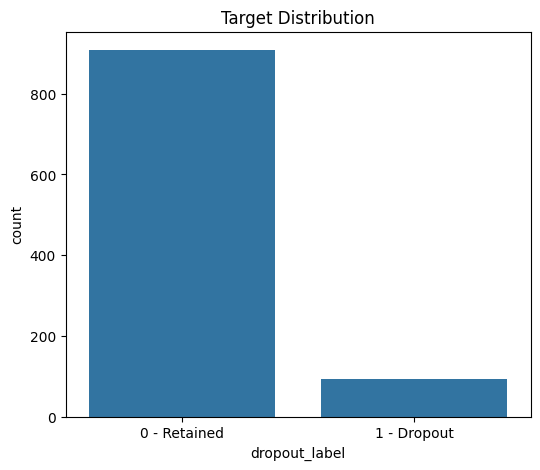

In [ ]:
plt.figure(figsize=(6,5))

sns.countplot(data=df,x=TARGET)

plt.title("Target Distribution")

plt.show()

In [ ]:
constant=[]

for col in df.columns:

    if df[col].nunique()==1:

        constant.append(col)

df=df.drop(columns=constant)

print(constant)

['academic_year', 'district']


In [ ]:
near_unique=[]

for col in df.columns:

    if df[col].nunique()>0.98*len(df):

        near_unique.append(col)

df=df.drop(columns=near_unique)

print(near_unique)

[]


In [ ]:
print(df.shape)

df.head()

(1000, 44)


,school_code,geographic_zone,school_type,data_source,enumerator_initials,date_recorded,gender,age_at_start_of_academic_year,class_level,grade_repetition_count,...,missed_school_for_choreswork,missed_school_due_to_illness,barriers_to_regular_attendance,family_income_level,parent_attends_school_events,behaviour_warnings_punishments,class_participation,extracurricular_activities,dropout_label,headteacher_confirmation_date
0,KNU_JHS,Peri-urban,Public,Questionnaire,OKT,2026-07-05 00:00:00,Male,10.0,JHS1,0,...,No,"Yes, more than once",Nothing-come regularly,Medium,Sometimes,Never,5.0,1 activity,0 - Retained,2026-07-05 00:00:00
1,KNU_JHS,Peri-urban,Public,Questionnaire,ET,2026-07-05 00:00:00,Male,11.0,JHS1,0,...,No,"Yes, more than once",Nothing-come regularly,Medium,Rarely,Once,2.0,2 activities,0 - Retained,2026-07-05 00:00:00
2,KNU_JHS,Peri-urban,Public,Questionnaire,KCJ,2026-07-05 00:00:00,Male,10.0,JHS1,0,...,Yes,"Yes, more than once",Health problems,Medium,Sometimes,Never,5.0,2 activities,0 - Retained,2026-07-05 00:00:00
3,KNU_JHS,Peri-urban,Public,Questionnaire,OKT,2026-07-05 00:00:00,Female,12.0,JHS1,0,...,No,"Yes, once",Nothing-come regularly,High,Often,Never,4.0,2 activities,0 - Retained,2026-07-05 00:00:00
4,KNU_JHS,Peri-urban,Public,Questionnaire,VT,2026-07-05 00:00:00,Female,10.0,JHS1,0,...,No,"Yes, more than once",Nothing-come regularly,High,Sometimes,Never,4.0,1 activity,0 - Retained,2026-07-05 00:00:00


In [ ]:
# Columns that leak future information
leakage_cols = [
    "headteacher_confirmation_date",
    "dropout_date",
    "completion_date",
    "graduation_date",
    "status_after_program",
    "final_result"
]

# Remove only those that exist
existing_leakage = [col for col in leakage_cols if col in df.columns]

df.drop(columns=existing_leakage, inplace=True)

print("Removed leakage columns:")
print(existing_leakage)

Removed leakage columns:
['headteacher_confirmation_date']


In [ ]:
# Convert target to binary values
df["dropout_label"] = (
    df["dropout_label"]
      .astype(str)
      .str.strip()
      .map({
          "0 - Retained": 0,
          "1 - Dropout": 1
      })
)

print(df["dropout_label"].value_counts())

dropout_label
0    908
1     92
Name: count, dtype: int64


In [ ]:
unnecessary_cols = [
    "date_recorded",
    "enumerator_initials"
]

df.drop(columns=[c for c in unnecessary_cols if c in df.columns],
        inplace=True)

print("Removed unnecessary columns:", unnecessary_cols)

Removed unnecessary columns: ['date_recorded', 'enumerator_initials']


In [ ]:
df.to_csv(

    f"{PROJECT_DIR}/cleaned_data.csv",

    index=False

)

print("Dataset saved successfully.")

Dataset saved successfully.
